In [15]:
const PROJECT_ROOT = joinpath(homedir(), "work", "Deborah.jl")
function localpath(relpath::AbstractString)
    return joinpath(PROJECT_ROOT, relpath)
end
# Base.invokelatest(include, localpath("src/Deborah.jl"))
# import .Deborah
using Revise
import Deborah; flush(stdout); flush(stderr)

# ns=8
# nt=4
# b="1.64"
# kappa="13400"
ns=12
nt=4
b="1.60"
kappa="13585"
LBP="15"
TRP="40"

ensemble="L$(ns)T$(nt)b$(b)k$(kappa)"

work = "nf4_clover_wilson_finiteT"

collection = "."
model="Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM"

# # collection = "SAVE_results_LBP1-10"
# collection = "SAVE_results_LBP5-50"
# model="TrM1-TrM1_BAS_TrM1-TrM2_GBM_TrM1-TrM3_GBM_TrM1-TrM4_GBM"

collection_subdir1 = "analysis_$(ensemble)"
collection_subdir2 = "analysis_$(ensemble)_$(model)"

overall_name = "$(ensemble)_$(model)_LBP_$(LBP)_TRP_$(TRP)"

toml_path = localpath(joinpath(work, collection, collection_subdir1, collection_subdir2, overall_name, "config_Esther_$(overall_name).toml"))

jobid = nothing

cfg = 
Deborah.Esther.TOMLConfigEsther.parse_full_config_Esther(
    toml_path
)

paths = 
Deborah.Esther.PathConfigBuilderEsther.build_path_config_Esther(
    cfg.data, 
    cfg.abbrev;
    project_root=PROJECT_ROOT,
    subdir=collection
)

trace_data = 
Deborah.Esther.TraceDataLoader.load_trace_data(
    paths
)

Deborah.Rebekah.PyPlotLaTeX.set_pyplot_latex_style()

[2026-02-20 16:20:02.533] Reading config file: /home/benjamin/work/Deborah.jl/nf4_clover_wilson_finiteT/./analysis_L12T4b1.60k13585/analysis_L12T4b1.60k13585_Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM/L12T4b1.60k13585_Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM_LBP_15_TRP_40/config_Esther_L12T4b1.60k13585_Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM_LBP_15_TRP_40.toml
[2026-02-20 16:20:02.534] 
[2026-02-20 16:20:02.534] --------------------------------------------------
[2026-02-20 16:20:02.534] >> Models used in Deborah.jl = TrM1: LightGBM, TrM2: LightGBM, TrM3: LightGBM, TrM4: LightGBM
[2026-02-20 16:20:02.534] --------------------------------------------------
[2026-02-20 16:20:02.534] 


Histogram clipping is ON: [-18.3461, 0.0]
  OG discarded 21
  ML discarded 0
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./histogram_trdinv4_ul_L12T4b1.60k13585_Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM_LBP_15_TRP_40-crop.pdf'.


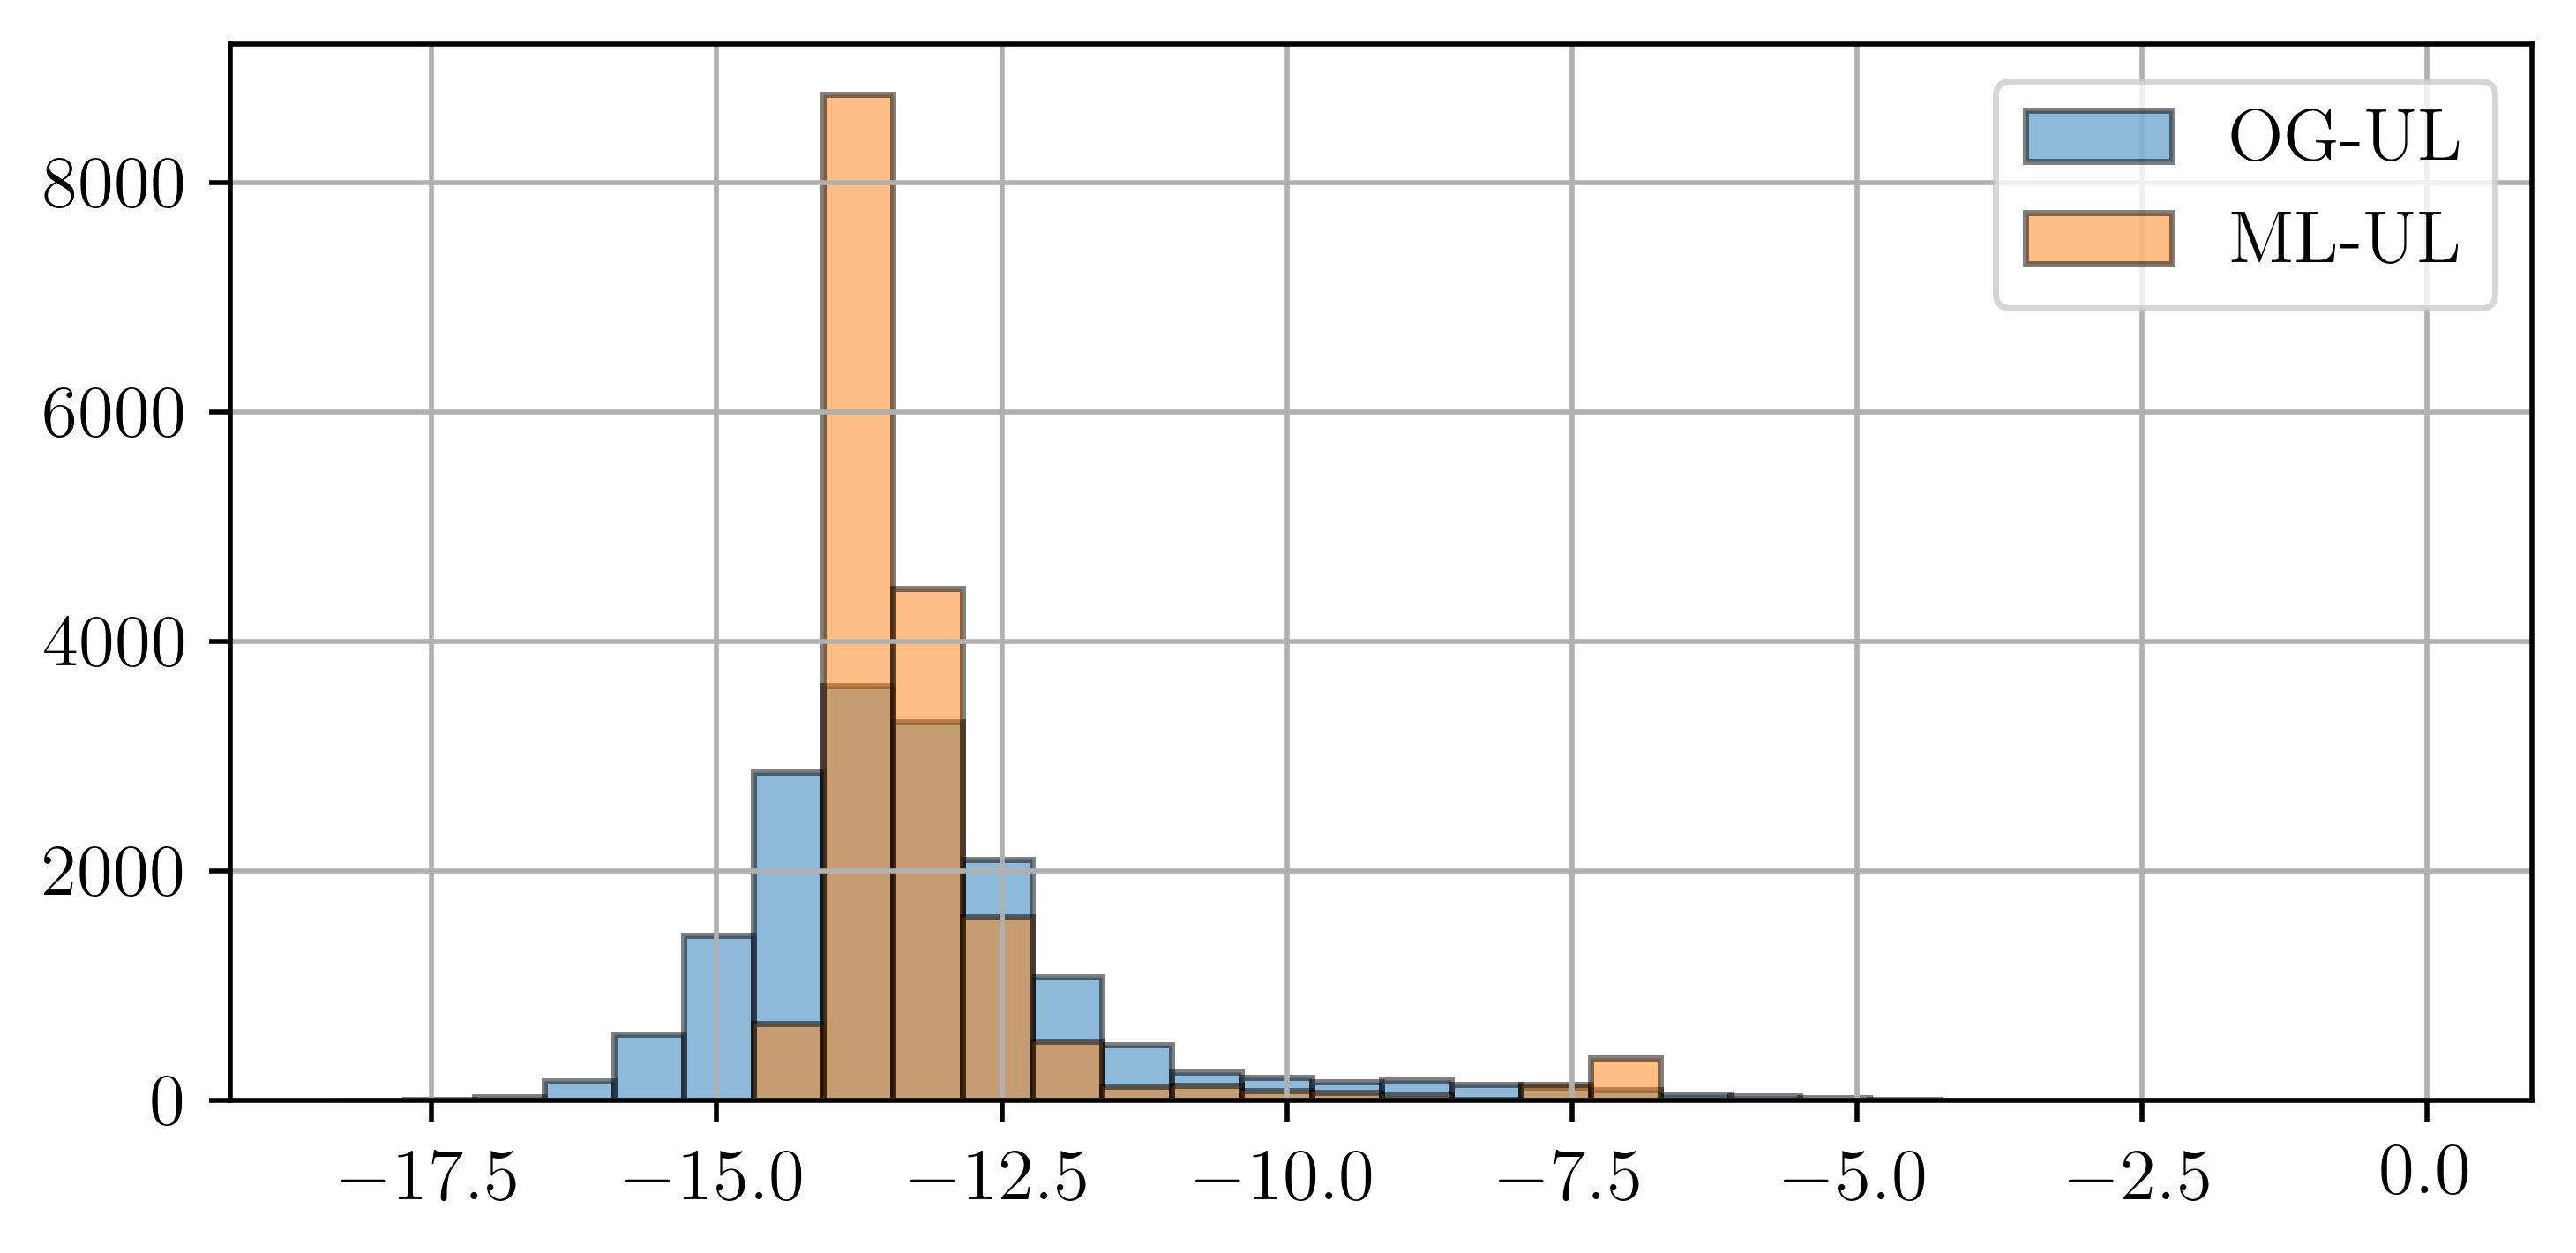

"saved plot ./histogram_trdinv4_ul_L12T4b1.60k13585_Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM_LBP_15_TRP_40.pdf"

"saved histogram_bins.dat"

In [18]:
trace_idx=4

nbins = 30

Deborah.Rahab.HistogramOrigML.plot_histogram_orig_vs_ml(
    trace_data,
    trace_idx,
    nbins,
    overall_name;
    subset="ul",
    x_max=0.0,
    save_file=true,
    plot_dir="."
)